🚀 Training hardware: cuda
   GPU Model: NVIDIA GeForce RTX 2050


C:\Users\cempl\AppData\Local\Temp\ipykernel_3288\3560177197.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=DE

🔄 Found existing brain at 'fusion_model.pth'. Loading weights to resume training...
✅ Model Architecture Ready.
✅ Dataset Loaded: 300 samples
⏳ Starting Training for 10 Epochs...


Epoch 1/10: 100%|██████████| 38/38 [00:06<00:00,  5.84it/s, loss=0.0000]


   Epoch 1 Average Loss: 0.000000


...

   Epoch 8 Average Loss: 0.000000


Epoch 9/10: 100%|██████████| 38/38 [00:05<00:00,  6.94it/s, loss=0.0000]


   Epoch 9 Average Loss: 0.000000


Epoch 10/10: 100%|██████████| 38/38 [00:04<00:00,  7.73it/s, loss=0.0000]


   Epoch 10 Average Loss: 0.000000
✅ Training Complete. Updated model saved as 'fusion_model.pth'.


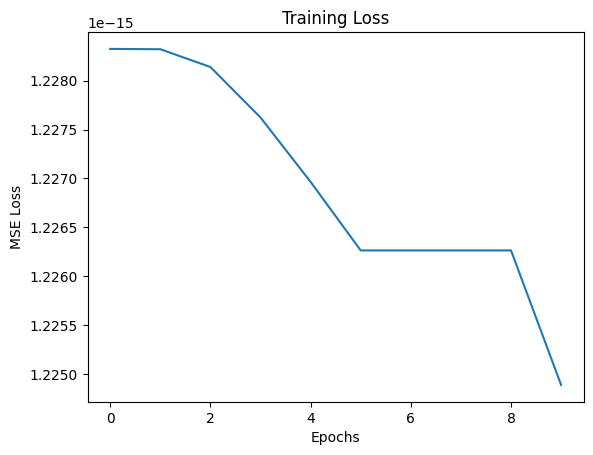

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
BATCH_SIZE = 8        # NVIDIA GPUs can usually handle larger batches. Lower to 4 if out of memory.
LEARNING_RATE = 0.0005 # Slightly lowered. When fine-tuning an already trained model, a lower LR prevents "forgetting" old data.
EPOCHS = 10           
IMG_SIZE = 128        
MODEL_PATH = "fusion_model.pth" # Defined path for saving/loading

# --- HARDWARE SETUP: NATIVE CUDA ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training hardware: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU Model: {torch.cuda.get_device_name(0)}")

# --- 1. THE MODEL ---
class FusionNet(nn.Module):
    def __init__(self):
        super(FusionNet, self).__init__()
        self.enc1 = nn.Conv2d(6, 32, kernel_size=3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=2) 
        self.enc3 = nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=2)
        self.bottle = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.dec3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.final = nn.Conv2d(32, 3, kernel_size=3, padding=1)
        
    def forward(self, x):
        e1 = F.relu(self.enc1(x))
        e2 = F.relu(self.enc2(e1))
        e3 = F.relu(self.enc3(e2))
        b = F.relu(self.bottle(e3))
        d3 = F.relu(self.dec3(b))
        d2 = F.relu(self.dec2(d3))
        return torch.sigmoid(self.final(d2))

model = FusionNet().to(DEVICE)

# --- CONTINUOUS LEARNING LOGIC ---
if os.path.exists(MODEL_PATH):
    print(f"🔄 Found existing brain at '{MODEL_PATH}'. Loading weights to resume training...")
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
else:
    print("🆕 No existing model found. Starting training from scratch.")

print("✅ Model Architecture Ready.")

# --- 2. THE WARPING FUNCTION ---
def warp_tensor(img_tensor, flow_tensor):
    N, C, H, W = img_tensor.shape
    xx = torch.arange(0, W).view(1, -1).repeat(H, 1)
    yy = torch.arange(0, H).view(-1, 1).repeat(1, W)
    xx = xx.view(1, 1, H, W).repeat(N, 1, 1, 1)
    yy = yy.view(1, 1, H, W).repeat(N, 1, 1, 1)
    
    grid = torch.cat((xx, yy), 1).float()
    if img_tensor.device.type != 'cpu':
        grid = grid.to(DEVICE)
        
    vgrid = grid + flow_tensor
    vgrid[:, 0, :, :] = 2.0 * vgrid[:, 0, :, :] / max(W - 1, 1) - 1.0
    vgrid[:, 1, :, :] = 2.0 * vgrid[:, 1, :, :] / max(H - 1, 1) - 1.0
    vgrid = vgrid.permute(0, 2, 3, 1)
    
    return F.grid_sample(img_tensor, vgrid, align_corners=True)

# --- 3. DATASET LOADER ---
class FrameTripletDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.triplets = []
        flow_dir = os.path.join(root_dir, 'flow')
        for root, _, files in os.walk(flow_dir):
            for file in files:
                if file.endswith('.npy'):
                    self.triplets.append(os.path.join(root, file))
    
    def __len__(self):
        return len(self.triplets)
    
    def __getitem__(self, idx):
        flow_path = self.triplets[idx]
        rel_path = os.path.relpath(flow_path, os.path.join(self.root_dir, 'flow'))
        base_img_path = os.path.join(self.root_dir, 'triplets', rel_path.replace('.npy', ''))
        
        img0 = cv2.imread(base_img_path + '_0.png')
        img1 = cv2.imread(base_img_path + '_1.png')
        img2 = cv2.imread(base_img_path + '_2.png')
        flow = np.load(flow_path)
        
        if img0 is None or img1 is None or img2 is None:
            return torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.zeros((3, IMG_SIZE, IMG_SIZE)), torch.zeros((2, IMG_SIZE, IMG_SIZE))

        img0 = cv2.resize(img0, (IMG_SIZE, IMG_SIZE))
        img1 = cv2.resize(img1, (IMG_SIZE, IMG_SIZE))
        img2 = cv2.resize(img2, (IMG_SIZE, IMG_SIZE))
        flow = cv2.resize(flow, (IMG_SIZE, IMG_SIZE))
        
        img0 = torch.from_numpy(img0).permute(2, 0, 1).float() / 255.0
        img1 = torch.from_numpy(img1).permute(2, 0, 1).float() / 255.0
        img2 = torch.from_numpy(img2).permute(2, 0, 1).float() / 255.0
        flow = torch.from_numpy(flow).permute(2, 0, 1).float()
        
        return img0, img1, img2, flow

dataset = FrameTripletDataset(root_dir='dataset')
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"✅ Dataset Loaded: {len(dataset)} samples")

# --- 4. TRAINING LOOP ---
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()
loss_history = []

print(f"⏳ Starting Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    epoch_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for img0, target, img2, flow in progress_bar:
        img0, target, img2, flow = img0.to(DEVICE), target.to(DEVICE), img2.to(DEVICE), flow.to(DEVICE)
        
        warped_0 = warp_tensor(img0, flow * 0.5)      
        warped_1 = warp_tensor(img2, flow * -0.5)     
        
        cnn_input = torch.cat([warped_0, warped_1], dim=1)
        output = model(cnn_input)
        
        loss = criterion(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
        
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"   Epoch {epoch+1} Average Loss: {avg_loss:.6f}")

# This will overwrite the old file with the newly improved weights
torch.save(model.state_dict(), MODEL_PATH)
print(f"✅ Training Complete. Updated model saved as '{MODEL_PATH}'.")

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()